In [76]:
from data.fetcher import fetch_data

df = fetch_data("DIXON.NS",period='1mo',interval='15m')

[*********************100%%**********************]  1 of 1 completed


In [18]:
df.head()

,Datetime,Open,High,Low,Close,Adj Close,Volume
0,2024-06-06 09:15:00,9548.500000,9605.900391,9470.349609,9586.450195,9586.450195,24341
1,2024-06-06 09:30:00,9589.500000,9674.200195,9560.349609,9662.450195,9662.450195,34096
2,2024-06-06 09:45:00,9667.950195,9849.500000,9660.099609,9731.900391,9731.900391,59781
3,2024-06-06 10:00:00,9725.099609,9755.900391,9701.400391,9732.000000,9732.000000,19129
4,2024-06-06 10:15:00,9732.299805,9740.000000,9673.099609,9713.450195,9713.450195,16792


In [70]:
# -*- coding: utf-8 -*-
from pandas import DataFrame
from pandas_ta.overlap import ma
from pandas_ta.utils import get_offset, non_zero_range, verify_series


def stoch(high, low, close, k=None, d=None, smooth_k=None, mamode=None, offset=None, **kwargs):
    """Indicator: Stochastic Oscillator (STOCH)"""
    # Validate arguments
    k = k if k and k > 0 else 14
    d = d if d and d > 0 else 3
    smooth_k = smooth_k if smooth_k and smooth_k > 0 else 3
    _length = max(k, d, smooth_k)
    high = verify_series(high, _length)
    low = verify_series(low, _length)
    close = verify_series(close, _length)
    offset = get_offset(offset)
    mamode = mamode if isinstance(mamode, str) else "sma"

    if high is None or low is None or close is None: return

    # Calculate Result
    lowest_low = low.rolling(k).min()
    highest_high = high.rolling(k).max()

    stoch = 100 * (close - lowest_low)
    stoch /= non_zero_range(highest_high, lowest_low)

    stoch_k = ma(mamode, stoch.loc[stoch.first_valid_index():,], length=smooth_k)
    stoch_d = ma(mamode, stoch_k.loc[stoch_k.first_valid_index():,], length=d)

    # Offset
    if offset != 0:
        stoch_k = stoch_k.shift(offset)
        stoch_d = stoch_d.shift(offset)

    # Handle fills
    if "fillna" in kwargs:
        stoch_k.fillna(kwargs["fillna"], inplace=True)
        stoch_d.fillna(kwargs["fillna"], inplace=True)
    if "fill_method" in kwargs:
        stoch_k.fillna(method=kwargs["fill_method"], inplace=True)
        stoch_d.fillna(method=kwargs["fill_method"], inplace=True)

    # Name and Categorize it
    _name = "STOCH"
    _props = f"_{k}_{d}_{smooth_k}"
    stoch_k.name = f"{_name}k{_props}"
    stoch_d.name = f"{_name}d{_props}"
    stoch_k.category = stoch_d.category = "momentum"

    # Prepare DataFrame to return
    data = {stoch_k.name: stoch_k, stoch_d.name: stoch_d}
    df = DataFrame(data)
    df.name = f"{_name}{_props}"
    df.category = stoch_k.category
    return df


stoch.__doc__ = \
"""Stochastic (STOCH)

The Stochastic Oscillator (STOCH) was developed by George Lane in the 1950's.
He believed this indicator was a good way to measure momentum because changes in
momentum precede changes in price.

It is a range-bound oscillator with two lines moving between 0 and 100.
The first line (%K) displays the current close in relation to the period's
high/low range. The second line (%D) is a Simple Moving Average of the %K line.
The most common choices are a 14 period %K and a 3 period SMA for %D.

Sources:
    https://www.tradingview.com/wiki/Stochastic_(STOCH)
    https://www.sierrachart.com/index.php?page=doc/StudiesReference.php&ID=332&Name=KD_-_Slow

Calculation:
    Default Inputs:
        k=14, d=3, smooth_k=3
    SMA = Simple Moving Average
    LL  = low for last k periods
    HH  = high for last k periods

    STOCH = 100 * (close - LL) / (HH - LL)
    STOCHk = SMA(STOCH, smooth_k)
    STOCHd = SMA(FASTK, d)

Args:
    high (pd.Series): Series of 'high's
    low (pd.Series): Series of 'low's
    close (pd.Series): Series of 'close's
    k (int): The Fast %K period. Default: 14
    d (int): The Slow %K period. Default: 3
    smooth_k (int): The Slow %D period. Default: 3
    mamode (str): See ```help(ta.ma)```. Default: 'sma'
    offset (int): How many periods to offset the result. Default: 0

Kwargs:
    fillna (value, optional): pd.DataFrame.fillna(value)
    fill_method (value, optional): Type of fill method

Returns:
    pd.DataFrame: %K, %D columns.
"""

In [83]:
from pandas_ta.trend import adx
import pandas as pd

#adx_df = adx(df['High'], df['Low'], df['Close'], lensig=14)
stoch_df = stoch(df['High'], df['Low'], df['Close'])
combined_df = pd.concat([df, stoch_df], axis=1)
combined_df.tail()

,Datetime,Open,High,Low,Close,Adj Close,Volume,STOCHk_14_3_3,STOCHd_14_3_3
520,2024-07-05 14:15:00,12455.000000,12473.950195,12420.000000,12465.549805,12465.549805,14330,12.958295,8.622283
521,2024-07-05 14:30:00,12466.000000,12494.900391,12461.549805,12470.400391,12470.400391,12178,25.007259,14.575379
522,2024-07-05 14:45:00,12474.150391,12477.549805,12451.000000,12473.400391,12473.400391,12008,36.093056,24.686203
523,2024-07-05 15:00:00,12474.049805,12526.200195,12473.549805,12500.000000,12500.000000,30429,45.284322,35.461546
524,2024-07-05 15:15:00,12500.000000,12521.450195,12488.400391,12505.950195,12505.950195,19022,54.467767,45.281715


In [81]:
help(stoch)

Help on function stoch in module __main__:

stoch(high, low, close, k=None, d=None, smooth_k=None, mamode=None, offset=None, **kwargs)
    Stochastic (STOCH)
    
    The Stochastic Oscillator (STOCH) was developed by George Lane in the 1950's.
    He believed this indicator was a good way to measure momentum because changes in
    momentum precede changes in price.
    
    It is a range-bound oscillator with two lines moving between 0 and 100.
    The first line (%K) displays the current close in relation to the period's
    high/low range. The second line (%D) is a Simple Moving Average of the %K line.
    The most common choices are a 14 period %K and a 3 period SMA for %D.
    
    Sources:
        https://www.tradingview.com/wiki/Stochastic_(STOCH)
        https://www.sierrachart.com/index.php?page=doc/StudiesReference.php&ID=332&Name=KD_-_Slow
    
    Calculation:
        Default Inputs:
            k=14, d=3, smooth_k=3
        SMA = Simple Moving Average
        LL  = low for

In [80]:
import plotly.graph_objs as go

# Assuming df contains your data
data = combined_df[['Datetime', 'STOCHk_14_3_3', 'STOCHd_14_3_3']]

# Create a figure with Plotly
fig = go.Figure()

# Add a scatter trace for STOCHk_14_3_3
fig.add_trace(go.Scatter(x=data.index, y=data['STOCHk_14_3_3'], mode='lines+markers', name='STOCHk_14_3_3'))

# Add a scatter trace for STOCHd_14_3_3
fig.add_trace(go.Scatter(x=data.index, y=data['STOCHd_14_3_3'], mode='lines+markers', name='STOCHd_14_3_3'))

# Update the layout
fig.update_layout(title='STOCH Plot for Last Two Rows',
                  xaxis_title='Datetime',
                  yaxis_title='Value')

# Show the plot
fig.show()


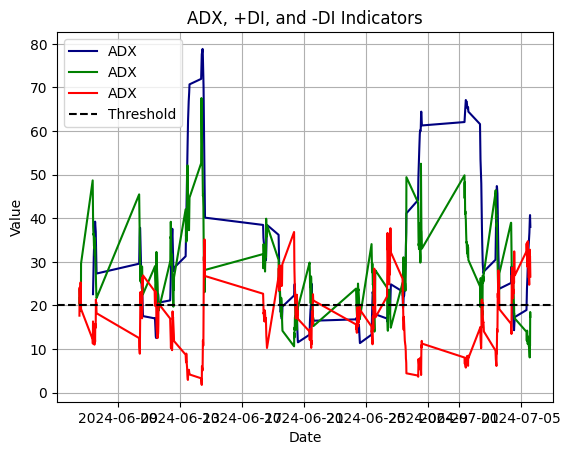

In [63]:
import pandas as pd
combined_df = pd.concat([df, adx_df], axis=1)
plt.plot(combined_df['Datetime'], combined_df['ADX_14'], label='ADX', color='navy')
plt.plot(combined_df['Datetime'], combined_df['DMP_14'], label='ADX', color='green')
plt.plot(combined_df['Datetime'], combined_df['DMN_14'], label='ADX', color='red')

plt.axhline(y=20, color='black', linestyle='--', label='Threshold')

plt.title('ADX, +DI, and -DI Indicators')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

In [64]:
import pandas as pd
import numpy as np
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import plotly.io as pio
import webbrowser

# Create interactive plot with Plotly
fig = make_subplots(rows=2, cols=1, shared_xaxes=True, vertical_spacing=0.1)

# ADX plot
fig.add_trace(go.Scatter(x=combined_df.index, y=combined_df['ADX_14'], mode='lines', name='ADX', line=dict(color='navy')), row=1, col=1)
fig.add_trace(go.Scatter(x=combined_df.index, y=combined_df['DMP_14'], mode='lines', name='+DI', line=dict(color='green')), row=1, col=1)
fig.add_trace(go.Scatter(x=combined_df.index, y=combined_df['DMN_14'], mode='lines', name='-DI', line=dict(color='red')), row=1, col=1)

# Horizontal line for the threshold
fig.add_trace(go.Scatter(x=combined_df.index, y=[20]*len(combined_df), mode='lines', name='Threshold', line=dict(color='black', dash='dash')), row=1, col=1)

# OHLC plot
fig.add_trace(go.Candlestick(x=combined_df.index,
                             open=combined_df['Open'],
                             high=combined_df['High'],
                             low=combined_df['Low'],
                             close=combined_df['Close'],
                             name='OHLC'), row=2, col=1)

fig.update_layout(title='ADX, +DI, and -DI Indicators with OHLC',
                  xaxis_title='Date',
                  yaxis_title='Value',
                  legend=dict(x=0.01, y=0.99, traceorder='normal', bgcolor='rgba(0,0,0,0)'),
                  template='plotly_dark')

# Save the plot to an HTML file and open it in a web browser
file_path = 'adx_di_plot.html'
pio.write_html(fig, file=file_path, auto_open=True)

# Open the plot in the default web browser
webbrowser.open(file_path)

True

In [21]:
combined_df.to_csv("ADX_info.csv", index=False)

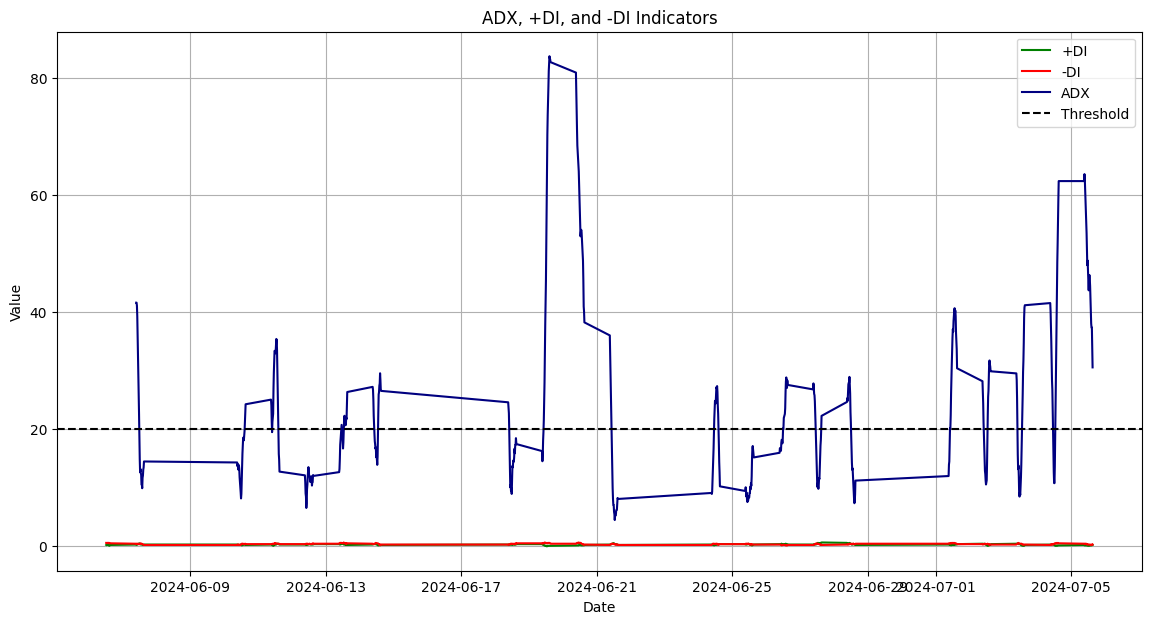

In [33]:
import pandas as pd
from pandas_ta.overlap import ma
from pandas_ta.volatility import atr
from pandas_ta.utils import verify_series, zero

# Function definition for ADX calculation including +DI and -DI
def adx_plus_di_minus_di(high, low, close, length=14):
    """Calculate ADX, +DI and -DI"""
    # Calculate ATR
    atr_ = atr(high=high, low=low, close=close, length=length)
    
    # Calculate the directional movements
    up = high.diff()
    down = low.diff()
    
    plus_dm = (up > down) & (up > 0) * up
    minus_dm = (down > up) & (down > 0) * down
    
    # Smooth the directional movements
    plus_dm = plus_dm.rolling(window=length).mean()
    minus_dm = minus_dm.rolling(window=length).mean()
    
    # Calculate the directional indexes
    plus_di = 100 * plus_dm / atr_
    minus_di = 100 * minus_dm / atr_
    
    # Calculate the DX
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    
    # Calculate the ADX
    adx = dx.rolling(window=length).mean()
    
    return adx, plus_dm, minus_dm

# Apply the function to calculate ADX, +DI, -DI
adx, plus_dm, minus_dm = adx_plus_di_minus_di(df['High'], df['Low'], df['Close'])

# Add the results to the original DataFrame
df['ADX'] = adx
df['+DI'] = plus_dm
df['-DI'] = minus_dm

# Print or use the combined DataFrame as needed
# df.to_csv("ADX_info.csv", index=False)

plt.figure(figsize=(14, 7))

plt.plot(df['Datetime'], df['+DI'], label='+DI', color='green')
plt.plot(df['Datetime'], df['-DI'], label='-DI', color='red')
plt.plot(df['Datetime'], df['ADX'], label='ADX', color='navy')

plt.axhline(y=20, color='black', linestyle='--', label='Threshold')

plt.title('ADX, +DI, and -DI Indicators')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()

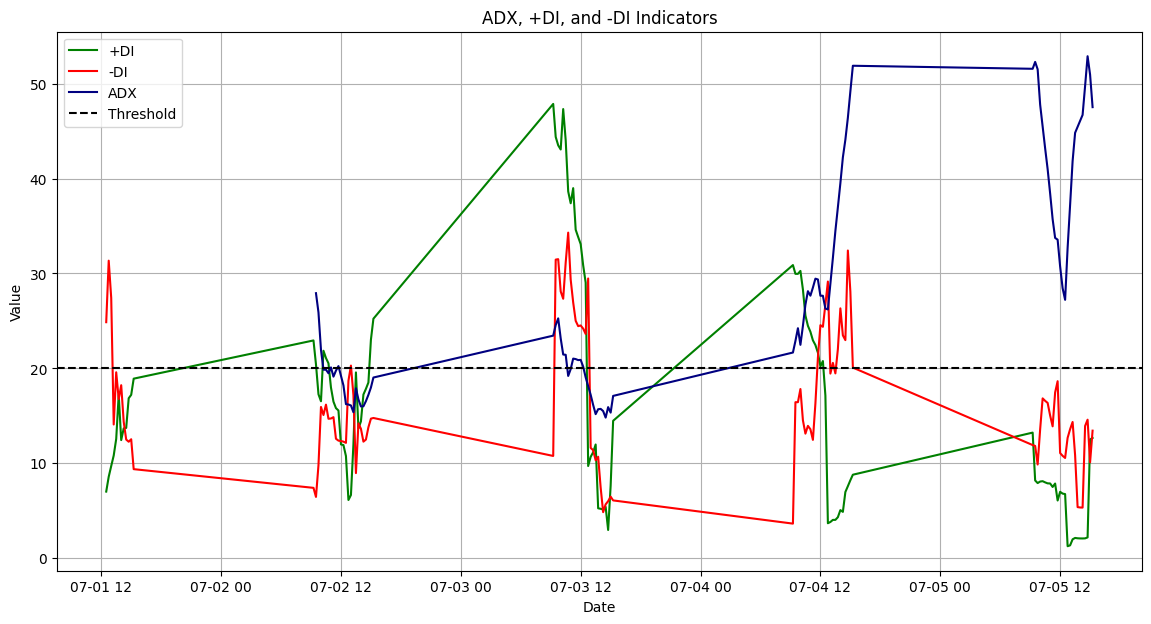

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Function to calculate ADX, +DI, and -DI
def adx_di(df, length=14, threshold=20):
    high = df['High']
    low = df['Low']
    close = df['Close']
    
    # True Range
    tr = pd.concat([high - low, (high - close.shift(1)).abs(), (low - close.shift(1)).abs()], axis=1).max(axis=1)
    
    # Directional Movement
    plus_dm = high.diff()
    minus_dm = low.diff()
    
    plus_dm = np.where((plus_dm > minus_dm) & (plus_dm > 0), plus_dm, 0.0)
    minus_dm = np.where((minus_dm > plus_dm) & (minus_dm > 0), minus_dm, 0.0)
    
    # Smoothing
    atr = tr.rolling(window=length).mean()
    plus_dm_smooth = pd.Series(plus_dm).rolling(window=length).mean()
    minus_dm_smooth = pd.Series(minus_dm).rolling(window=length).mean()
    
    # +DI and -DI
    plus_di = 100 * (plus_dm_smooth / atr)
    minus_di = 100 * (minus_dm_smooth / atr)
    
    # DX and ADX
    dx = 100 * (abs(plus_di - minus_di) / (plus_di + minus_di))
    adx = dx.rolling(window=length).mean()
    
    # Adding results to DataFrame
    df['TR'] = tr
    df['+DM'] = plus_dm
    df['-DM'] = minus_dm
    df['ATR'] = atr
    df['+DI'] = plus_di
    df['-DI'] = minus_di
    df['DX'] = dx
    df['ADX'] = adx
    
    return df

# Apply the function
result = adx_di(df)

# Plotting
plt.figure(figsize=(14, 7))

plt.plot(result['Datetime'], result['+DI'], label='+DI', color='green')
plt.plot(result['Datetime'], result['-DI'], label='-DI', color='red')
plt.plot(result['Datetime'], result['ADX'], label='ADX', color='navy')

plt.axhline(y=20, color='black', linestyle='--', label='Threshold')

plt.title('ADX, +DI, and -DI Indicators')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()
plt.grid()
plt.show()
